# Global COVID-19 Trend forecasting and risk analytics System

## 📊 Project Overview
This notebook implements an end-to-end analytics and forecasting pipeline for global COVID-19 data. The system includes robust data cleaning, advanced feature engineering, multi-model comparative analysis, and time-series forecasting.

### Key Features:
- **Data Preprocessing:** Standardized cleaning and outlier handling.
- **Feature Engineering:** Rolling averages, growth rates, and lag features.
- **Predictive Modeling:** Linear Regression, Random Forest, and XGBoost with Cross-Validation.
- **Forecasting:** 14-day future trend prediction.
- **Automated Reporting:** Results comparison and visualization export.

## 1. Environment Setup
First, we import the necessary libraries for data manipulation, visualization, and machine learning. We also configure the plotting style for professional-grade charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from datetime import timedelta
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### 2.1 Data Preprocessing Logic
This function standardizes column names, converts date strings to datetime objects, removes duplicate rows, and handles missing values through interpolation. It also clips outliers to ensure model stability.

In [2]:
def preprocess_data(df):
    """Handle missing values, duplicates, and standardization."""
    # Standardize column names
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
    
    # Convert date
    df['date'] = pd.to_datetime(df['date'])
    
    # Remove duplicates
    df = df.drop_duplicates()
    
    # Handle missing values: Interpolate numeric columns grouped by country
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df.groupby('country')[numeric_cols].transform(lambda x: x.interpolate().ffill().bfill().fillna(0))
    
    # Outlier handling (IQR) for key target variables
    for col in ['new_cases', 'new_deaths']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR > 0:
            df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
        
    return df

### 2.2 Feature Engineering Logic
Here we derive new features like 7-day rolling averages, daily growth rates, mortality rates, and temporal components (month/week). Lag features are also created to provide historical context to the models.

In [3]:
def create_features(df):
    """Feature engineering: rolling averages, lags, rates, temporal features."""
    df = df.sort_values(['country', 'date'])
    
    # 1. Rolling Averages (7-day)
    df['cases_7d_avg'] = df.groupby('country')['new_cases'].transform(lambda x: x.rolling(7).mean()).fillna(0)
    df['deaths_7d_avg'] = df.groupby('country')['new_deaths'].transform(lambda x: x.rolling(7).mean()).fillna(0)
    
    # 2. Daily Growth Percentage
    df['growth_rate'] = df.groupby('country')['new_cases'].pct_change().replace([np.inf, -np.inf], 0).fillna(0)
    
    # 3. Mortality Rate
    df['mortality_rate'] = (df['total_deaths'] / df['total_cases']).replace([np.inf, -np.inf], 0).fillna(0)
    
    # 4. Temporal features
    df['month'] = df['date'].dt.month
    df['week'] = df['date'].dt.isocalendar().week.astype(int)
    
    # 5. Lag features
    df['lag_1'] = df.groupby('country')['new_cases'].shift(1).fillna(0)
    df['lag_7'] = df.groupby('country')['new_cases'].shift(7).fillna(0)
    
    return df

### 2.3 Model Training and Evaluation Logic
This function splits the data, scales features, and trains three distinct models: Linear Regression, Random Forest, and XGBoost. It calculates performance metrics like MAE, RMSE, and R², along with 5-fold cross-validation scores.

In [4]:
def train_models(X, y):
    """Train multiple models and evaluate performance with cross-validation."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
    }
    
    results = []
    trained_models = {}
    
    for name, model in models.items():
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
        
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        
        results.append({
            'Model': name,
            'MAE': mean_absolute_error(y_test, preds),
            'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
            'R2 Score': r2_score(y_test, preds),
            'CV R2 Mean': cv_scores.mean()
        })
        trained_models[name] = model
        
    return trained_models, pd.DataFrame(results), X_test_scaled, y_test, scaler

### 2.4 Visualization Logic
This function generates and saves key plots: a correlation heatmap, global trends with moving averages, model performance comparisons, and feature importance rankings.

In [5]:
def plot_results(df, comparison_df, y_test, predictions, feature_importance, output_dir='../visualizations'):
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Heatmap
    plt.figure(figsize=(12, 10))
    corr = df[['new_cases', 'total_cases', 'new_deaths', 'total_deaths', 'cases_7d_avg', 'deaths_7d_avg', 'growth_rate', 'mortality_rate', 'lag_1', 'lag_7']].corr()
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
    plt.title('Correlation Heatmap of Key Features')
    plt.savefig(f"{output_dir}/correlation_heatmap.png")
    plt.show()
    
    # 2. Trend Plot
    plt.figure(figsize=(14, 6))
    global_trend = df.groupby('date')[['new_cases', 'cases_7d_avg']].sum().reset_index()
    plt.plot(global_trend['date'], global_trend['new_cases'], alpha=0.3, label='Daily Cases')
    plt.plot(global_trend['date'], global_trend['cases_7d_avg'], color='red', linewidth=2, label='7-Day MA')
    plt.title('Global COVID-19 Trend (Actual vs Moving Average)')
    plt.legend()
    plt.savefig(f"{output_dir}/trend_analysis.png")
    plt.show()
    
    # 3. Model Comparison
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Model', y='R2 Score', data=comparison_df, palette='viridis')
    plt.title('Model Performance Comparison (R² Score)')
    plt.ylim(0, 1.1)
    plt.savefig(f"{output_dir}/model_comparison.png")
    plt.show()
    
    # 4. Importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='magma')
    plt.title('Top 10 Feature Importance (XGBoost)')
    plt.savefig(f"{output_dir}/feature_importance.png")
    plt.show()

### 2.5 Forecasting Logic
This function performs recursive forecasting for the next 14 days by aggregating the latest global state and iteratively predicting future values while updating temporal and lag features.

In [6]:
def forecast_global(model, df, features, scaler, days=14):
    last_date = df['date'].max()
    latest_global = df[df['date'] == last_date][features].mean().to_frame().T
    
    forecast_values = []
    dates = [last_date + timedelta(days=i) for i in range(1, days + 1)]
    current_input = latest_global.copy()
    
    for i in range(days):
        scaled_input = scaler.transform(current_input)
        pred = model.predict(scaled_input)[0]
        forecast_values.append(max(0, pred))
        
        current_input['total_cases'] += pred
        current_input['lag_7'] = current_input['lag_1']
        current_input['lag_1'] = pred
        current_input['month'] = dates[i].month
        current_input['week'] = dates[i].week
        
    return pd.DataFrame({'Date': dates, 'Predicted_New_Cases': forecast_values})

## 3. Pipeline Execution

### 3.1 Data Loading and Cleaning
We load the raw `compact.csv` dataset and apply our preprocessing function to clean and stabilize the data.

In [7]:
print("Loading and cleaning data...")
raw_data = pd.read_csv("../data/compact.csv")
df = preprocess_data(raw_data)
print(f"Data cleaned. Shape: {df.shape}")

Loading and cleaning data...
Data cleaned. Shape: (570606, 61)


### 3.2 Feature Engineering
We generate rolling averages, rates, and lags to prepare the dataset for predictive modeling.

In [8]:
print("Engineering features...")
df = create_features(df)
print("Features engineered successfully.")

Engineering features...
Features engineered successfully.


### 3.3 Model Training and Comparison
We select the target and features, sample the data for performance if necessary, and run the comparative training pipeline.

In [9]:
features = ['total_cases', 'cases_7d_avg', 'deaths_7d_avg', 'growth_rate', 
            'mortality_rate', 'month', 'week', 'lag_1', 'lag_7', 
            'population_density', 'gdp_per_capita', 'diabetes_prevalence']
target = 'new_cases'

X = df[features]
y = df[target]

if len(df) > 50000:
    X = df.sample(50000, random_state=42)[features]
    y = df.sample(50000, random_state=42)[target]

trained_models, results_df, X_test_scaled, y_test, scaler = train_models(X, y)
print("Model training complete. Comparison results:")
display(results_df)

Model training complete. Comparison results:


,Model,MAE,RMSE,R2 Score,CV R2 Mean
0,Linear Regression,4.094278,10.991723,0.909222,0.910436
1,Random Forest,1.507785,6.432284,0.968913,0.969239
2,XGBoost,1.418445,6.080409,0.972221,0.971831


### 3.4 Automated Visualization
We generate and save professional-grade plots to the `visualizations` folder.

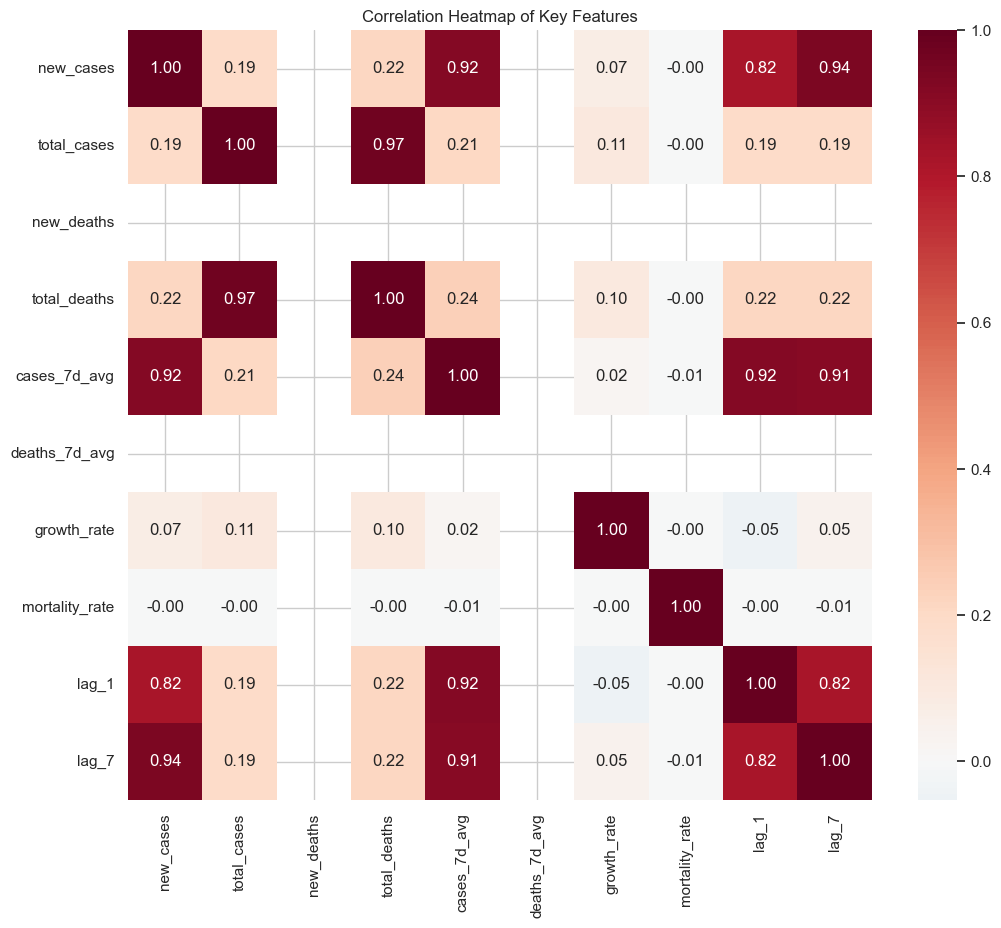

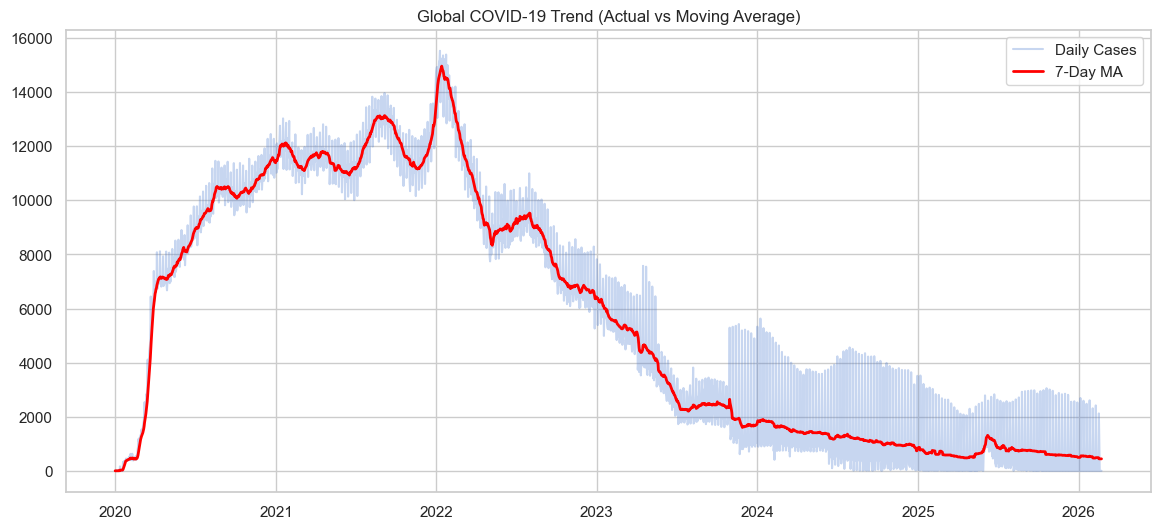

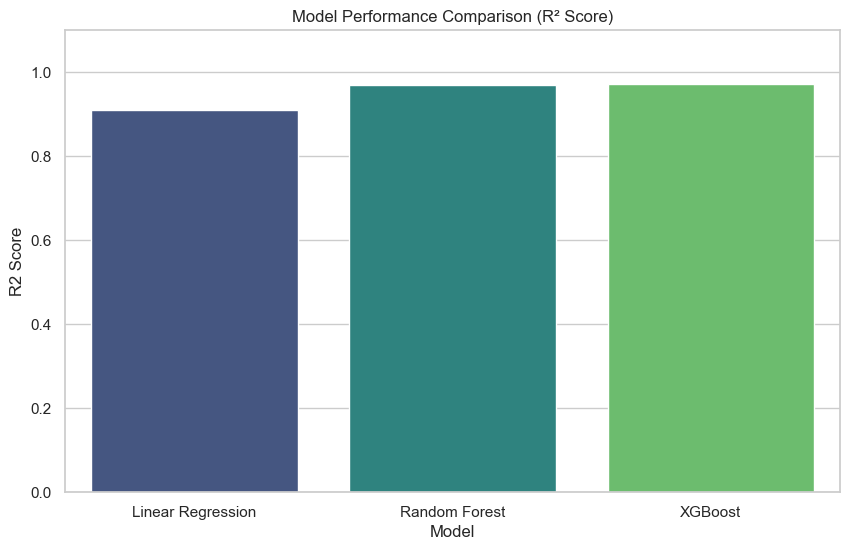

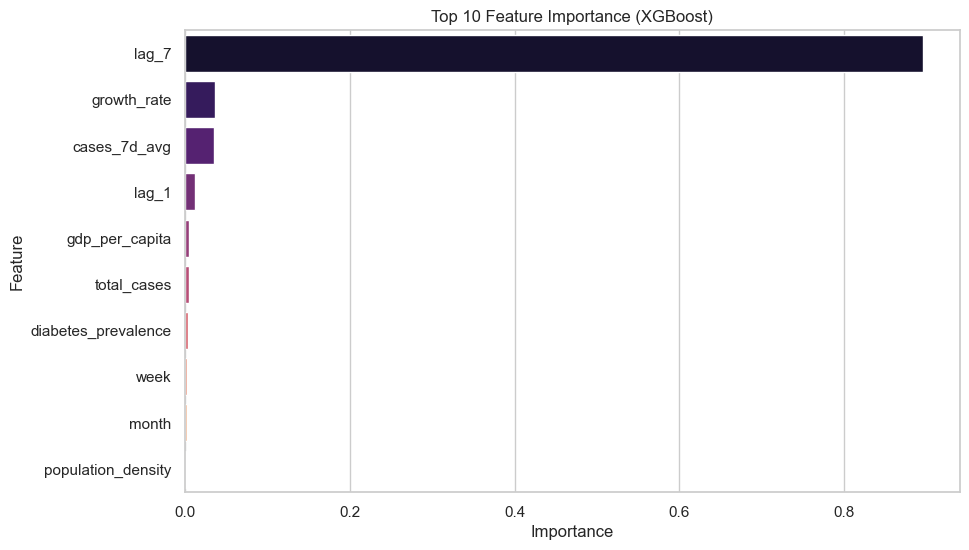


--- Top Correlated Features with New Cases ---


,new_cases
new_cases,1.000000
lag_7,0.942382
cases_7d_avg,0.916923
lag_1,0.823171
total_cases,0.190985
gdp_per_capita,0.142691
growth_rate,0.073517
week,0.020345
month,0.015925
diabetes_prevalence,0.002483


In [10]:
importances = trained_models['XGBoost'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)

predictions = trained_models['XGBoost'].predict(X_test_scaled)
plot_results(df, results_df, y_test, predictions, feature_importance_df)

print("\n--- Top Correlated Features with New Cases ---")
display(df[features + [target]].corr()[target].sort_values(ascending=False).to_frame())

### 3.5 Future Trend Forecasting
We predict global cases for the next 14 days and visualize the anticipated trend.

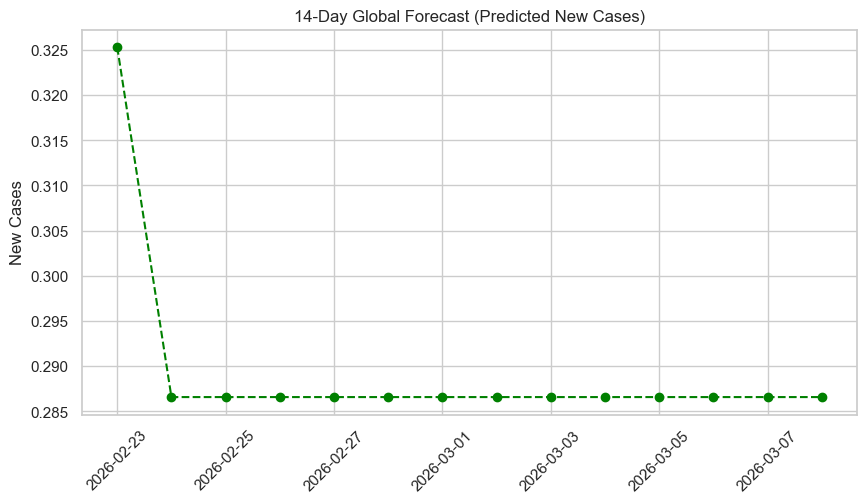

--- Forecast Summary Table ---


,Date,Predicted_New_Cases
0,2026-02-23,0.325305
1,2026-02-24,0.286570
2,2026-02-25,0.286570
3,2026-02-26,0.286570
4,2026-02-27,0.286570
5,2026-02-28,0.286570
6,2026-03-01,0.286570
7,2026-03-02,0.286570
8,2026-03-03,0.286570
9,2026-03-04,0.286570


In [11]:
forecast_df = forecast_global(trained_models['XGBoost'], df, features, scaler)

plt.figure(figsize=(10, 5))
plt.plot(forecast_df['Date'], forecast_df['Predicted_New_Cases'], marker='o', color='green', linestyle='--')
plt.title('14-Day Global Forecast (Predicted New Cases)')
plt.ylabel('New Cases')
plt.xticks(rotation=45)
plt.savefig('../visualizations/future_forecast.png')
plt.show()

print("--- Forecast Summary Table ---")
display(forecast_df)

### 3.6 Final Artifact Exports
We save the cleaned data and the trained model/scaler for production use or further analysis.

In [12]:
print("Saving final artifacts...")
df.to_csv("../data/cleaned_covid_data.csv", index=False)

os.makedirs("../models", exist_ok=True)
joblib.dump(trained_models['XGBoost'], "../models/covid_xgb_model.joblib")
joblib.dump(scaler, "../models/scaler.joblib")

print("\nPipeline execution successfully finalized.")
print("- Cleaned dataset: ../data/cleaned_covid_data.csv")
print("- Saved Model: ../models/covid_xgb_model.joblib")
print("- Visualizations: ../visualizations/")

Saving final artifacts...

Pipeline execution successfully finalized.
- Cleaned dataset: ../data/cleaned_covid_data.csv
- Saved Model: ../models/covid_xgb_model.joblib
- Visualizations: ../visualizations/
